# Stage 5 — CNN Spectrogram Model

## Architecture and Comparison to Classical Baseline

We train a CNN on mel-spectrograms to learn 2D time-frequency patterns without handcrafted features. Training is done via `python scripts/train_cnn.py`, which uses a **speaker-disjoint split** (same convention as Stage 4) to avoid inflated metrics from speaker overlap.

## Evaluation Setup

- **Speaker-disjoint split:** No speaker/source appears in both train and test (see `evaluation-conventions.mdc`).
- **Preprocessing:** Per-sample spectrogram normalization (no global stats leakage).

## Architecture

- **Input:** Mel-spectrogram (128 bins × time)
- **Blocks:** Conv2D → BatchNorm → ReLU → MaxPool → Dropout (×4)
- **Pooling:** AdaptiveAvgPool2d → Flatten → FC(256→64) → FC(64→2)
- **Rationale:** Learns 2D patterns; middle ground between classical (handcrafted) and transformers (end-to-end).

In [7]:
import sys
from pathlib import Path

import torch
import json

PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT))

from config import OUTPUTS_DIR
from src.models.cnn_spectrogram import SpectrogramCNN

In [8]:
model = SpectrogramCNN(n_mels=128, n_classes=2)
total = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total:,}")

Parameters: 405,378


In [9]:
# Load results if available
res_path = OUTPUTS_DIR / "cnn_results.json"
if res_path.exists():
    with open(res_path) as f:
        cnn_metrics = json.load(f)
    print("CNN Test Metrics:", cnn_metrics)
else:
    print("Run: python scripts/train_cnn.py")

CNN Test Metrics: {'accuracy': 0.6472898664571878, 'precision': 0.8781925343811395, 'recall': 0.5359712230215827, 'f1': 0.6656738644825019, 'confusion_matrix': [[377, 62], [387, 447]], 'auc_roc': 0.697018239622425}


## Results and Visualizations

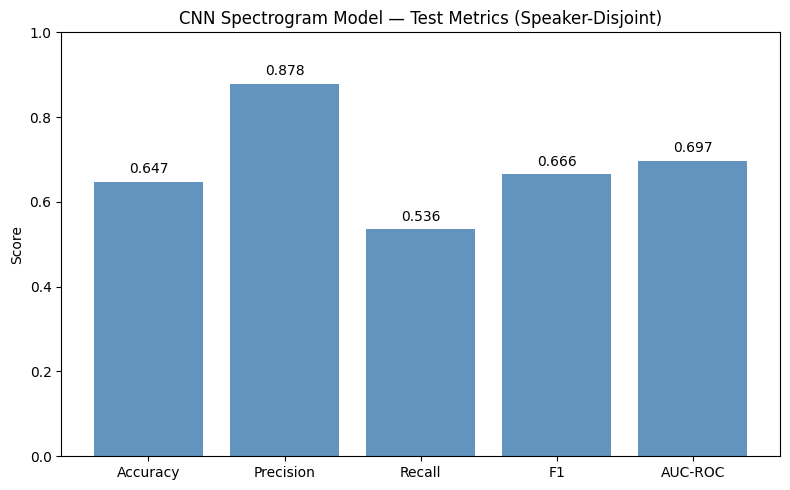

In [10]:
import matplotlib.pyplot as plt
import numpy as np

res_path = OUTPUTS_DIR / "cnn_results.json"
if not res_path.exists():
    raise FileNotFoundError("Run: python scripts/train_cnn.py")

with open(res_path) as f:
    cnn_metrics = json.load(f)

# Bar chart of metrics
fig, ax = plt.subplots(figsize=(8, 5))
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
values = [cnn_metrics["accuracy"], cnn_metrics["precision"], cnn_metrics["recall"],
          cnn_metrics["f1"], cnn_metrics["auc_roc"]]
bars = ax.bar(metrics, values, color="steelblue", alpha=0.85)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("CNN Spectrogram Model — Test Metrics (Speaker-Disjoint)")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{v:.3f}",
            ha="center", fontsize=10)
plt.tight_layout()
plt.show()

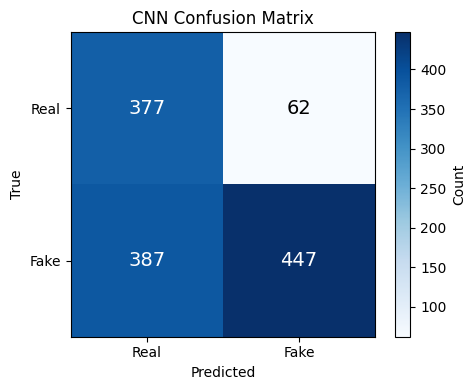

In [11]:
# Confusion matrix heatmap
cm = np.array(cnn_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Real", "Fake"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["Real", "Fake"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("CNN Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

## Comparison to Classical Baseline

The CNN learns representations directly from spectrograms rather than pre-defined acoustic features. It can capture local time-frequency structures that may be hard to express with handcrafted features. Compare F1 and AUC with Stage 4 (RF, LR); both use speaker-disjoint evaluation for fair comparison.